In [1]:
import pandas as pd
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.stats import sigma_clip
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.inspection import partial_dependence

import scipy.integrate

# Helper Function That Plots The Scatter with Error Bars #

In [2]:
# Helper funciton that plots the scatter and error bars. 
# ax - matplotlib axis where the plots will be drawn. 
# mask - the mask that selects which rows to use. 
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.

nbins = 10

def scatter_with_errors(ax, xcol, nbins=None):
    # Raw values
    x = df[xcol].values
    y = df["residual_centered"].values
    yerr = yerr_all.values

    # --- sigma clipping in y (vertical axis) ---
    # NOTE: sigma clipping has been moved OUTSIDE this function.
    # This function now assumes `mask` already includes whatever global sigma-clip
    # (or other cleaning) you want. In other words: this function only plots.
    #
    # UPDATE: we no longer pass a mask into this function because we now DROP
    # any unwanted rows upstream (sigma-clip + physical cuts). Therefore the
    # dataframe `df` is already the final cleaned sample when this function is called.

    # --- scatter cloud ---
    ax.scatter(x, y, **point_kwargs)

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    ax.errorbar(
        x, y, yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.5,
        alpha=0.25,
        zorder=2,
    )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange")

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here.

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin.
    # NOTE: here we want to just count the number of points in each bin on the
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the
    # value and simply choose "count" as our statistics option.
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on.
    # Bin centers are just calcualted as the middle points between one bin edge and another.
    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals.
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array.
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # If a bin is empty, skip it (avoid divide-by-zero)
        if np.sum(in_bin) == 0:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue

        # We end up finding data and errro associated
        # with the number of bin that we are in.
        y_bin = y[in_bin]
        err_bin = yerr[in_bin]

        # inverse-variance weights
        w = 1.0 / (err_bin**2)

        # weighted mean
        y_mean = np.sum(w * y_bin) / np.sum(w)

        # propagated error on the mean
        err_mean = 1.0 / np.sqrt(np.sum(w))

        binned_y.append(y_mean)
        binned_yerr.append(err_mean)

    # Convert to arrays and only plot finite bins
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color="blue",
        markersize=5,
        capsize=3,
        zorder=5  # Keeps the data looking on top
    )

# Data Overview #

776 SNe before paper-based quality cuts.
579 SNe after paper-based quality cuts.


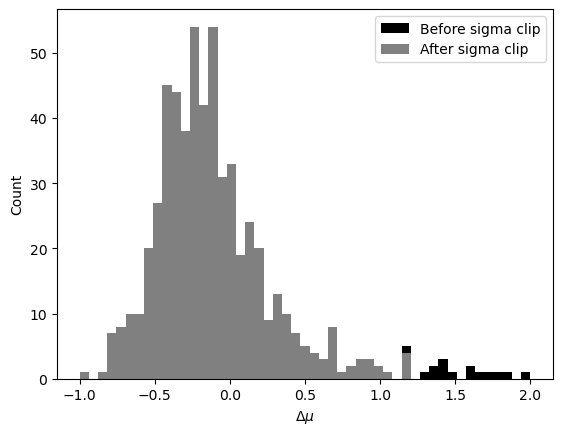

563 SNe after sigma clipping (Δμ)
555 SNe after SFR <= 2.5 cut.
553 SNe after DN4000 >= 0.5 cut.
550 SNe after AGE >= 2 Gyr cut.


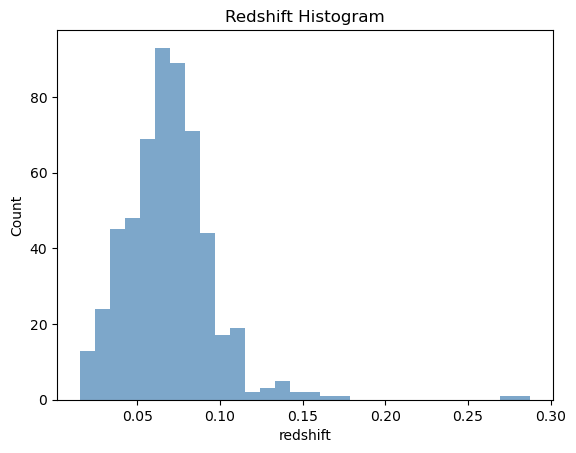

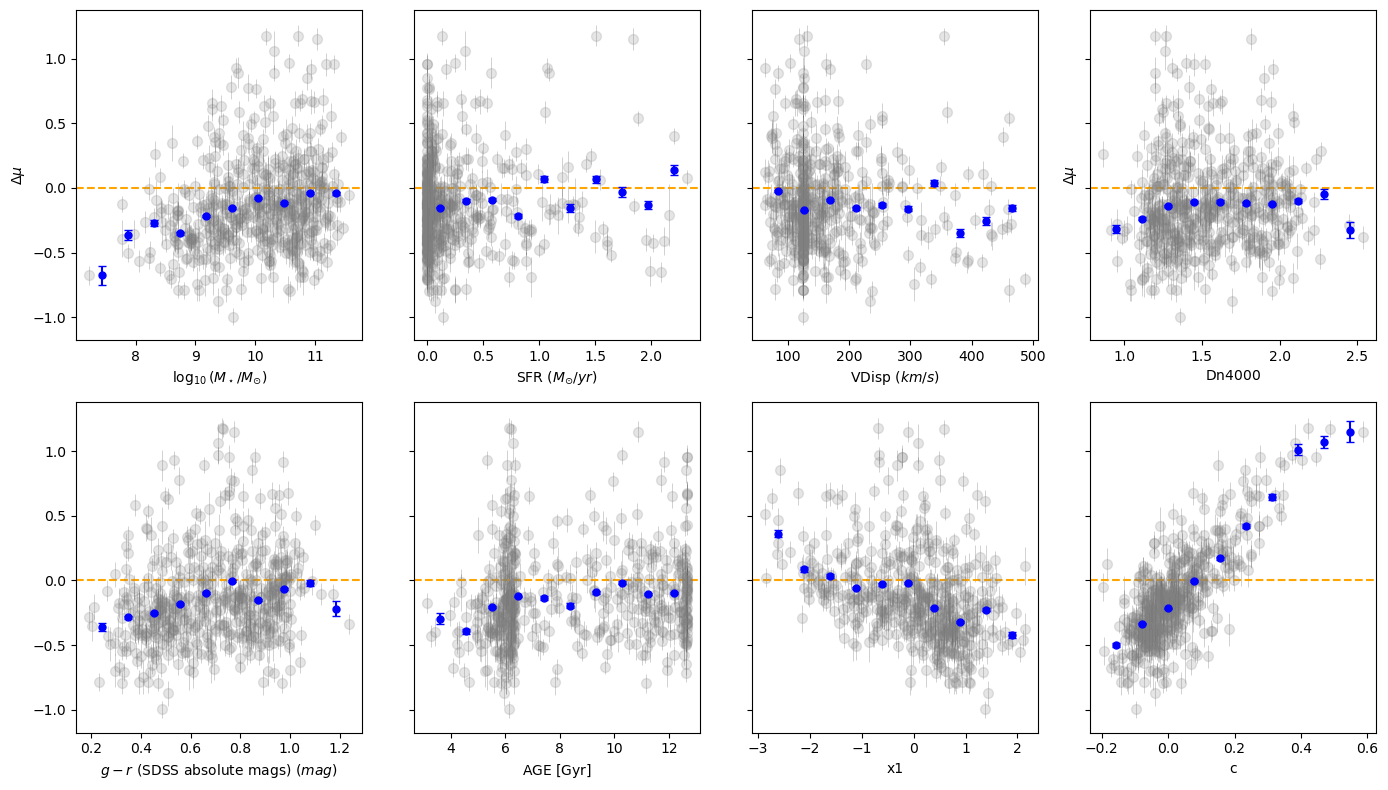

In [3]:
df = pd.read_csv("ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv")

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]


# ---------------------------------
# GLOBAL sigma-clip on residuals 
# ---------------------------------
# note: this only needs to get done once.
# We will be deleting the entries in the data frame. 

resid_before = df["residual_centered"]

# drop all residuals that that are sigma clipped.
clip = sigma_clip(df["residual_centered"], sigma=3, maxiters=1)
mask_sigma = ~clip.mask  # True = keep
df = df.loc[mask_sigma].reset_index(drop=True)

#Plot for visual inspetion
resid_bins = np.linspace(-1, 2, 50)
plt.hist(resid_before, bins=resid_bins, label="Before sigma clip", color = "black")
plt.hist(df["residual_centered"], bins=resid_bins, label="After sigma clip", color = "gray")
plt.xlabel(r"$\Delta \mu$")
plt.ylabel("Count")
plt.legend()
plt.show()

print(len(df), "SNe after sigma clipping (Δμ)", flush=True)


# ----------------------------------------------------------
# Define Which Data to Drop Before the Final Plots Are Shown
# ----------------------------------------------------------
# Note: we are not deciding to do any cuts to LOGMSTAR, VDISP, SDSS g-r, x1, or c.

mask_sfr    = (df["SFR"] <= 2.5)
mask_dn4000 = df["DN4000"] >= 0.5
mask_age    = df["AGE"] >= 2
combined_mask = ((df["SFR"] <= 2.5) & (df["DN4000"] >= 0.5) & (df["AGE"] >= 2))

# --------------------------------------
# Apply physical cuts one at a time
# and report how many SNe each cut removes
# --------------------------------------

# ---- 1) SFR cut ----
mask_sfr = df["SFR"] <= 2.5
n_after_sfr = np.sum(mask_sfr)
print(n_after_sfr, "SNe after SFR <= 2.5 cut.")
df = df.loc[mask_sfr].reset_index(drop=True)

# ---- 2) DN4000 cut ----
mask_dn4000 = df["DN4000"] >= 0.5
n_after_dn4000 = np.sum(mask_dn4000)
print(n_after_dn4000, "SNe after DN4000 >= 0.5 cut.")
df = df.loc[mask_dn4000].reset_index(drop=True)

# ---- 3) AGE cut ----
mask_age = df["AGE"] >= 2
n_after_age = np.sum(mask_age)
print(n_after_age, "SNe after AGE >= 2 Gyr cut.") 
df = df.loc[mask_age].reset_index(drop=True)

# # ---- 4) Redshift Cut ----
# mask_redshift = df["redshift"] <= 0.06
# n_after_redshift = np.sum(mask_redshift)
# print(n_after_redshift, "SNe after redshift <= 0.06 cut.")
# df = df.loc[mask_redshift].reset_index(drop=True)

# ---------------------------------
# redshift histogram 
# ---------------------------------

plt.figure()
plt.hist(df["redshift"], bins=30, color="steelblue",  alpha=0.7)
plt.xlabel("redshift")
plt.ylabel("Count")
plt.title("Redshift Histogram")
plt.show()


# -----------------------------
# Read the y-err collumn 
# -----------------------------
# note: must be done after all the sigma clipping
# and physical cuts have been taken care of. 
yerr_all = df["sigma_mu_meas"]


# ****************************************************************************
# ----------------------------------------------------------------------------
# Set up 2x4 grid - RESIDUALS + LIGHT CURVE PARAMETERS + ERRORS + BINS w/t ERRORS
# ----------------------------------------------------------------------------
# ****************************************************************************

# global number of bins
nbins = 10

fig, axes = plt.subplots(2, 4, figsize=(14, 8), sharey=True)
axes = axes.flatten()

point_kwargs = dict(alpha=0.2, s=50, color="grey", zorder=3)   

# --------------------------------------
# 1) LOGMSTAR
# --------------------------------------
ax = axes[0]

# # finite values mask (same as before)
# mask_logm = np.ones(len(df), dtype=bool)
# print(np.sum(mask_logm), "SNe after LOGMSTAR cut.")

# NOTE: we no longer define masks here because we now DROP any unwanted rows
# upstream (sigma-clip + physical cuts). Therefore the dataframe `df` is already
# the final cleaned sample when plotting.

# Use helper function with binning ON
scatter_with_errors(ax, "LOGMSTAR", nbins=nbins)

# Axis labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# 2) SFR (cut SFR > 2.5)
# --------------------------------------
ax = axes[1]

# Exclude SFR > 2.5
# NOTE: this cut is now applied upstream by dropping rows from df,
# so we do not define a mask here anymore.

scatter_with_errors(ax, "SFR", nbins=nbins)

ax.set_xlabel(r"${\rm SFR}\ (M_{\odot}/yr)$")

# --------------------------------------
# 3) VDISP
# --------------------------------------
ax = axes[2]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "VDISP", nbins=nbins)

ax.set_xlabel(r"${\rm VDisp }\  (km/s) $")

# --------------------------------------
# 4) DN4000  (cut DN4000 < 0.5)
# --------------------------------------
ax = axes[3]

# keep only finite values AND DN4000 >= 0.5
# NOTE: this cut is now applied upstream by dropping rows from df,
# so we do not define a mask here anymore.

scatter_with_errors(ax, "DN4000", nbins=nbins)

ax.set_xlabel(r"${\rm Dn4000}$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# 5) SDSS g - r
# --------------------------------------
ax = axes[4]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "SDSS_g_minus_r", nbins=nbins)

ax.set_xlabel(r"$g - r~{\rm (SDSS ~ absolute ~ mags)}\ (mag)$")

# --------------------------------------
# 6) AGE  (cut AGE < 2)
# --------------------------------------
ax = axes[5]

# keep only finite AGE and AGE >= 2
# NOTE: this cut is now applied upstream by dropping rows from df,
# so we do not define a mask here anymore.

scatter_with_errors(ax, "AGE", nbins=nbins)

ax.set_xlabel(r"${\rm AGE}\ [{\rm Gyr}]$")

# --------------------------------------
# 7) x1 
# --------------------------------------
ax = axes[6]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "x1", nbins=nbins)

ax.set_xlabel("x1")

# --------------------------------------
# 8) c 
# --------------------------------------
ax = axes[7]

# NOTE: we assume df has already been cleaned upstream, so we do not apply
# an isfinite mask here anymore.

scatter_with_errors(ax, "c", nbins=nbins)

ax.set_xlabel("c")

# --------------------------------------
# Global cosmetics
# --------------------------------------


fig.tight_layout()
plt.show()


# Note to keep in line with Mi's Example, we are only Using x1,c, an hostmass #

Also note: the data set has already been cut for the paper quality cuts as well as the host galaxy cuts. We're just using x1,c, and hostmass at the momoent for hte purpsoe of simplicity here. 

In [4]:
# =====================================================
# MI DAI ML TRAINING BLOCK 
# =====================================================

# Constructing the Random Forest Regressor Model
# Nothing is being fit here, uts just being made.

# Key properties of this model:
# - 1000 trees. 
# - Trees are allowed to grow deep (no max depth)
# - A minimum number of samples per leaf (5) enforces
#   local averaging and limits overfitting
# - At each split, only a subset of features is considered
#   (sqrt of total), encouraging diverse tree structures
# - Bootstrap resampling ensures each tree sees a slightly
#   different realization of the data

rf = GradientBoostingRegressor(
    learning_rate=0.01,
    n_estimators=2000,
    max_depth=2,
    subsample=0.9,
    random_state=42
)

# Defining Features and Setting Up Our Train/Test Split

feature_cols = [
    # "LOGMSTAR",
    "c",
    "x1",
    # "SFR",
    # "VDISP",
    # "DN4000",
    "SDSS_g_minus_r",
    # "AGE",
    # "redshift"
 ]

target_col = "residual_centered"

X = df[feature_cols]
y = df[target_col]


# -----------------------------------------------------
# Train / test split
# -----------------------------------------------------
# NOTE: we split X, y, *and* yerr together so that
# the measurement errors stay perfectly aligned with
# the training and testing samples.

Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=42
)

# -----------------------------------------------------
# Defining standard error as well as weights and fitting the model
# -----------------------------------------------------
# In real code each data point would have its own weight to contribute to the fit.
# NOTE: in this dataset we DO have per-point errors (sigma_mu_meas),
# so we use inverse-variance weighting here.

w = 1.0 / (yerr_tr**2)

rf.fit(Xtr, ytr, sample_weight=w)
yhat = rf.predict(Xte)

# Plots feature importance of x1, c, and hostmass in that order.
feature_importances = pd.Series(rf.feature_importances_, index=feature_cols)
print("Feature Importances:")
print(feature_importances.sort_values(ascending=False))

# # -----------------------------------------------------
# # Plotting Results (one subplot per feature, explicit code)
# # -----------------------------------------------------

# fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
# axes = axes.flatten()

# # --------------------------------------
# # LOGMSTAR
# # --------------------------------------
# ax = axes[0]
# ax.errorbar(
#     Xtr["LOGMSTAR"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder=1
#  )
# ax.scatter(
#     Xte["LOGMSTAR"], yhat,
#     alpha=0.6,
#     s=16,
#     color="orange",
#     label="Predictions",
#     zorder=2
#  )
# ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
# ax.set_ylabel(r"$\Delta \mu$")
# ax.legend()

# # --------------------------------------
# # c
# # --------------------------------------
# ax = axes[1]
# ax.errorbar(
#     Xtr["c"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder=1
#  )
# ax.scatter(
#     Xte["c"], yhat,
#     alpha=0.6,
#     s=16,
#     color="orange",
#     label="Predictions",
#     zorder=2
#  )
# ax.set_xlabel("c")
# ax.set_ylabel(r"$\Delta \mu$")
# ax.legend()

# # --------------------------------------
# # x1
# # --------------------------------------
# ax = axes[2]
# ax.errorbar(
#     Xtr["x1"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder=1
#  )
# ax.scatter(
#     Xte["x1"], yhat,
#     alpha=0.6,
#     s=16,
#     color="orange",
#     label="Predictions",
#     zorder=2
#  )
# ax.set_xlabel("x1")
# ax.set_ylabel(r"$\Delta \mu$")
# ax.legend()

# # --------------------------------------
# # SFR
# # --------------------------------------
# ax = axes[3]
# ax.errorbar(
#     Xtr["SFR"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder=1
#  )
# ax.scatter(
#     Xte["SFR"], yhat,
#     alpha=0.6,
#     s=16,
#     color="orange",
#     label="Predictions",
#     zorder=2
#  )
# ax.set_xlabel("SFR")
# ax.set_ylabel(r"$\Delta \mu$")
# ax.legend()

# # --------------------------------------
# # VDISP
# # --------------------------------------
# ax = axes[4]
# ax.errorbar(
#     Xtr["VDISP"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder=1
#  )
# ax.scatter(
#     Xte["VDISP"], yhat,
#     alpha=0.6,
#     s=16,
#     color="orange",
#     label="Predictions",
#     zorder=2
#  )
# ax.set_xlabel("VDISP")
# ax.set_ylabel(r"$\Delta \mu$")
# ax.legend()

# # --------------------------------------
# # DN4000
# # --------------------------------------
# ax = axes[5]
# ax.errorbar(
#     Xtr["DN4000"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder=1
#  )
# ax.scatter(
#     Xte["DN4000"], yhat,
#     alpha=0.6,
#     s=16,
#     color="orange",
#     label="Predictions",
#     zorder=2
#  )
# ax.set_xlabel("DN4000")
# ax.set_ylabel(r"$\Delta \mu$")
# ax.legend()

# # --------------------------------------
# # SDSS_g_minus_r
# # --------------------------------------
# ax = axes[6]
# ax.errorbar(
#     Xtr["SDSS_g_minus_r"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder=1
#  )
# ax.scatter(
#     Xte["SDSS_g_minus_r"], yhat,
#     alpha=0.6,
#     s=16,
#     color="orange",
#     label="Predictions",
#     zorder=2
#  )
# ax.set_xlabel("SDSS_g_minus_r")
# ax.set_ylabel(r"$\Delta \mu$")
# ax.legend()

# # --------------------------------------
# # AGE
# # --------------------------------------
# ax = axes[7]
# ax.errorbar(
#     Xtr["AGE"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder=1
#  )
# ax.scatter(
#     Xte["AGE"], yhat,
#     alpha=0.6,
#     s=16,
#     color="orange",
#     label="Predictions",
#     zorder=2
#  )
# ax.set_xlabel("AGE")
# ax.set_ylabel(r"$\Delta \mu$")
# ax.legend()

# # --------------------------------------
# # redshift
# # --------------------------------------
# ax = axes[8]
# ax.errorbar(
#     Xtr["redshift"], ytr,
#     yerr=yerr_tr,
#     fmt="o",
#     markersize=4,
#     alpha=0.25,
#     color="gray",
#     ecolor="gray",
#     elinewidth=0.5,
#     capsize=0,
#     label="Training data",
#     zorder=1
#  )
# ax.scatter(
#     Xte["redshift"], yhat,
#     alpha=0.6,
#     s=16,
#     color="orange",
#     label="Predictions",
#     zorder=2
#  )
# ax.set_xlabel("redshift")
# ax.set_ylabel(r"$\Delta \mu$")
# ax.legend()

# fig.tight_layuot()
# plt.show()

Feature Importances:
c                 0.761325
x1                0.189044
SDSS_g_minus_r    0.049631
dtype: float64


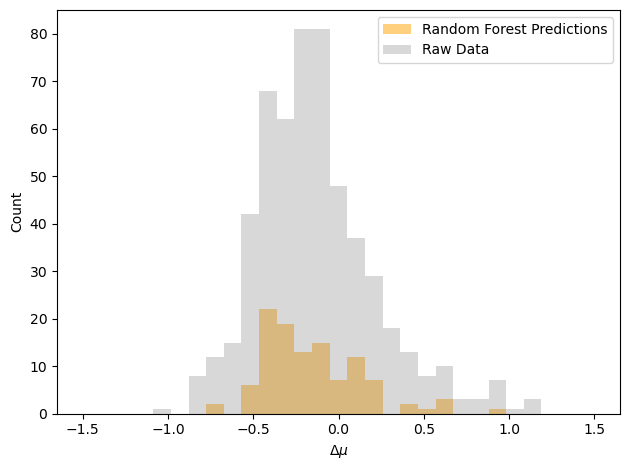

In [5]:
# --------------------------------------
# Compare distributions of raw residuals vs RF predictions
# --------------------------------------

# Use full-sample residuals (this is your cleaned df at this point)
y = df[target_col].to_numpy()

bins = np.linspace(-1.5,1.5,30)

# RF predictions (test set)
plt.hist(
    yhat,
    bins=bins,
    alpha=0.5,
    color="orange",
    label="Random Forest Predictions"
)

# Raw data (full sample)
plt.hist(
    y,
    bins=bins,
    alpha=0.3,
    color="grey",
    label="Raw Data"
)

plt.xlabel(r"$\Delta \mu$")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### Partial dependence via empirical marginalization

The model prediction may be written as $f(M, x_1, c)$. 

The partial dependence function corresponds to the expectation value of the model prediction at fixed $M$, marginalized over the remaining features.

In practice, this marginalization is performed empirically using the observed distribution of $(x_1, c)$ in the dataset rather than by numerical integration over a continuous probability density. For a dataset containing $N$ samples, the partial dependence is estimated as:

$$
f_{\mathrm{PD}}(M)
=
\frac{1}{N}
\sum_{i=1}^{N}
f\!\left(M,\; x_{1,i},\; c_i\right)
$$

Note the placement of the subscript i denoting how we sum up over all the x1 and c values. 

`partial_dependence` is a utility specifically designed to "probe" a fitted predictor such as a trained ML model/estimator. 
Works on with already-fit predictor. 

The actual interpetation of this function is a little bit more complex than that and it lies within the `method` argument that we parse into the machine learning algorythm. Here is the distinction between `brute` and `recursion`:

The partial dependence is evaluated on a grid of stellar-mass values $\{M^{(k)}\}$, producing a one-dimensional function $f_{\mathrm{PD}}(M^{(k)})$ that summarizes the model-predicted trend with host mass. For tree-based models such as Random Forests, this expectation value is computed efficiently using a recursive traversal of the decision trees, rather than explicit evaluation on a multidimensional feature grid. 


### What `method="brute"` does (the literal implementation)

The `brute` method corresponds to the textbook definition of partial dependence.

For each grid value $M_j$:

1. Construct $N$ samples of the form  
   $(M_j,\; x_{1,i},\; c_i)$,  
   where $(x_{1,i}, c_i)$ are taken from the observed dataset.
2. Evaluate the model prediction $f$ on all $N$ samples.
3. Average the resulting predictions.

This procedure is a direct numerical evaluation of

$$
f_{\mathrm{PD}}(M_j)
=
\frac{1}{N}
\sum_{i=1}^{N}
f\!\left(M_j,\; x_{1,i},\; c_i\right).
$$

**Pros:**
- Extremely transparent
- Matches the defining equation of partial dependence exactly in both spirit and implementation
- Applicable to any estimator with a prediction method

**Cons:**
- Computationally expensive for large $N$, many grid points, or large ensembles
- Inefficient for tree-based models, as the same tree structures are repeatedly evaluated

---

### What `method="recursion"` does (tree-aware acceleration)

The key conceptual point is that the recursive method does **not** skip marginalization.  
It computes the same expectation, but exploits the structure of tree-based models to do so more efficiently.

For decision tree ensembles, the model prediction is:
- Piecewise constant
- Defined by paths through decision trees

Rather than explicitly looping over all samples, the recursive algorithm:
- Traverses the tree structure
- Tracks the fraction of the training data flowing through each branch
- Computes weighted averages of leaf predictions

As a result, it evaluates a quantity equivalent to

$$
\mathbb{E}_{x_1,\,c}\!\left[f(M,\; x_1,\; c)\right],
$$

without explicitly enumerating every $(x_{1,i}, c_i)$ pair.

The expectation being estimated is therefore identical to that of the brute-force approach; only the computational strategy differs.






In [6]:
# # Defines a data frame 
# X_pd = X[feature_cols]

# print(X_pd.head())

# print("raw min/max:", X_pd["LOGMSTAR"].min(), X_pd["LOGMSTAR"].max())
# print("PD  min/max:", x1_grid.min(), x1_grid.max())

# # Parital dependence of "features" while marginalizing over what is not
# # defined as features. See above markdown description for an example where
# # functional dependance 
# res = partial_dependence(
#     estimator=rf,
#     X=X_pd, # Must indicate the full feature set.
#     features=["LOGMSTAR"],  # The feature who's dependance we want.
#     method="recursion",     # best to use for tree based estimators.
#     percentiles=(0.00, 1.00)
# )

# # The grid of M values where PD is Evaulated. This is the horizontal axis of the plot.
# x1_grid = res["grid_values"][0]
# # The corresponding PD values (average residuals after marginalization) at each point in the grid. This is the vertical axis of the plot.
# y_grid  = res["average"][0]

# fig, ax = plt.subplots(figsize=(10, 6))
# plt.scatter(x1_grid, y_grid, alpha=0.6, s=50, color = "orange", label="Predicted Features after Marginalization")

# # --------------------------------------
# # Raw data Plot with Error Bars 
# # --------------------------------------
# point_kwargs = {**point_kwargs, "label": "Raw Data"} # Hacky way to add a label.
# scatter_with_errors(ax, "LOGMSTAR", nbins=nbins)
# ax.errorbar([], [], fmt="o", color="blue", markersize=5, label="Binned Raw data") # Hacy way to add a label.

# # --------------------------------------
# # Axis Labels and Legend
# # --------------------------------------
# ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
# ax.set_ylabel(r"$\Delta \mu$")
# plt.legend()

# plt.show()

In [7]:
# # --------------------------------------
# # Linear fit to raw data
# # --------------------------------------
# x_raw = df["LOGMSTAR"]
# y_raw = df[target_col]
# coef = np.polyfit(x_raw, y_raw, 1)
# print("Linear fit coefficients (slope, intercept):", coef)
# x_fit = np.linspace(x_raw.min(), x_raw.max(), 200)
# y_fit = np.polyval(coef, x_fit)

# ax.plot(x_fit, y_fit, color="blue", linewidth=2, label="Linear fit (raw data)")

Linear fit coefficients for c (slope, intercept): [ 2.47196582 -0.18072489]
Linear fit coefficients for c (limited range, slope, intercept): [ 2.37110554 -0.18202379]
Linear fit coefficients for c (ml prediction, slope, intercept): [ 2.45195027 -0.18208528]
Linear fit coefficients for x1 (slope, intercept): [-0.13262667 -0.12945507]


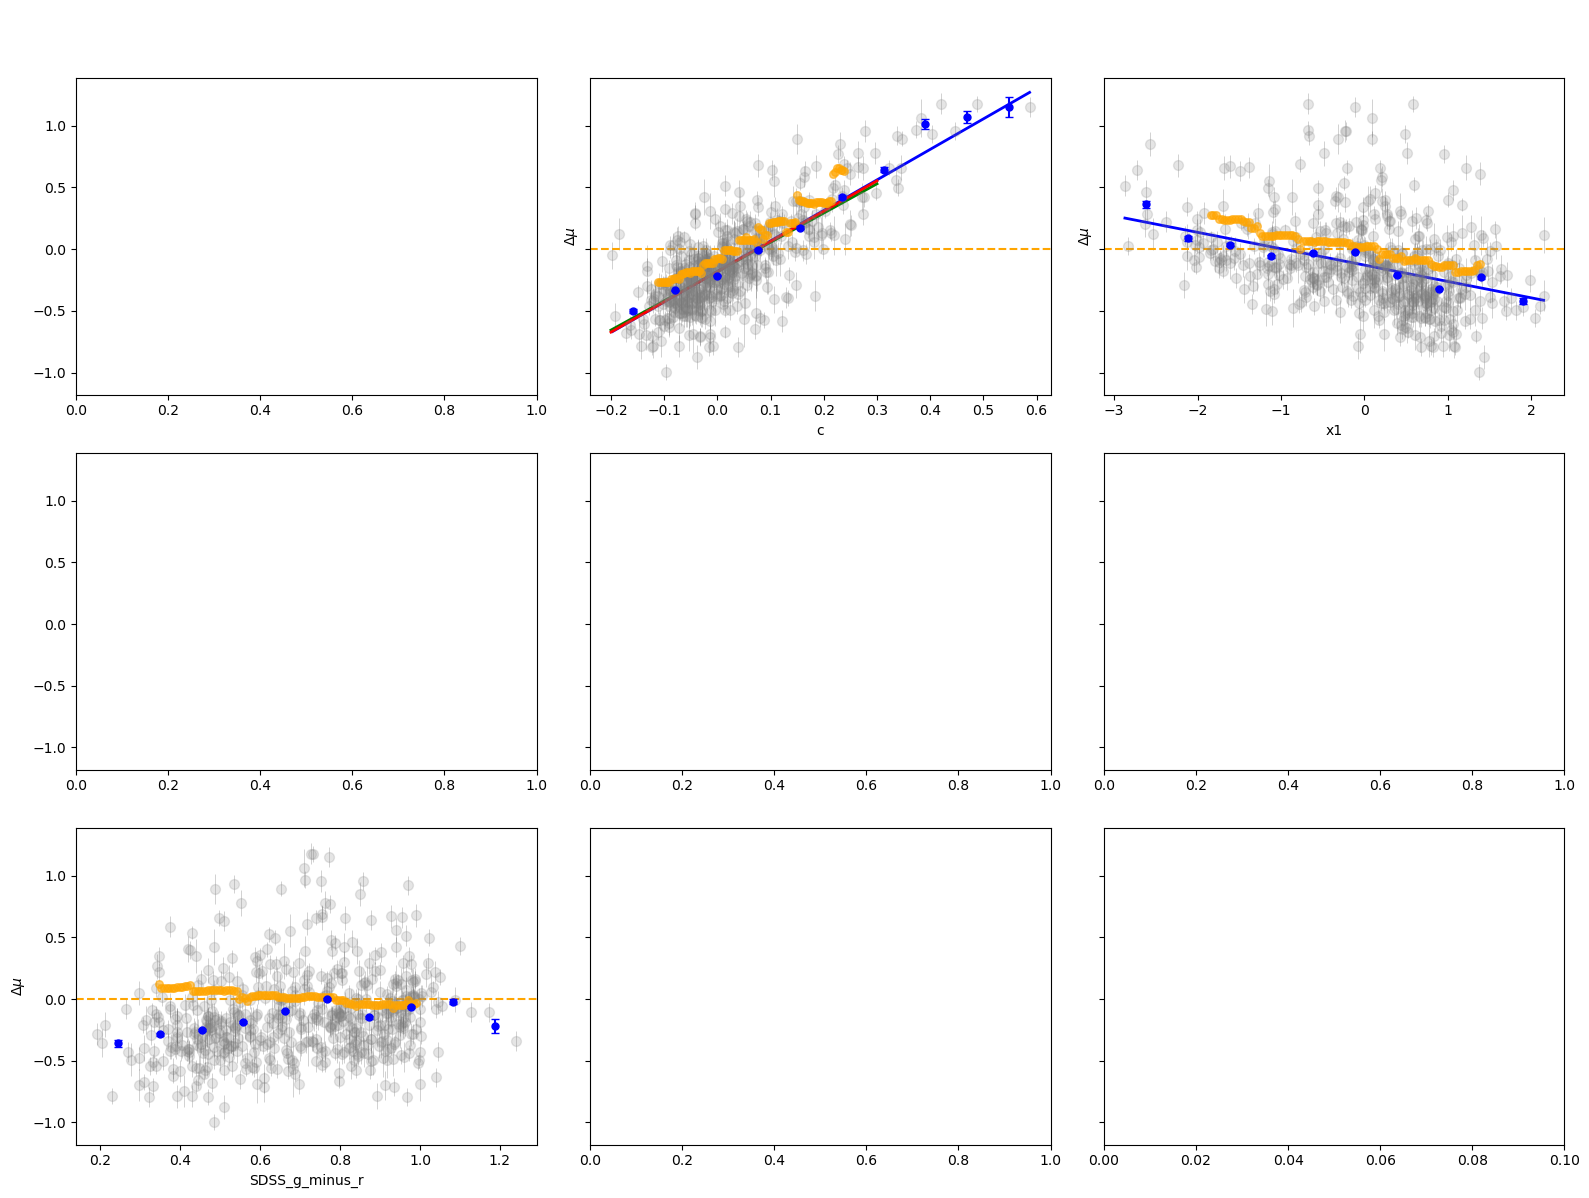

0.1412335815505068


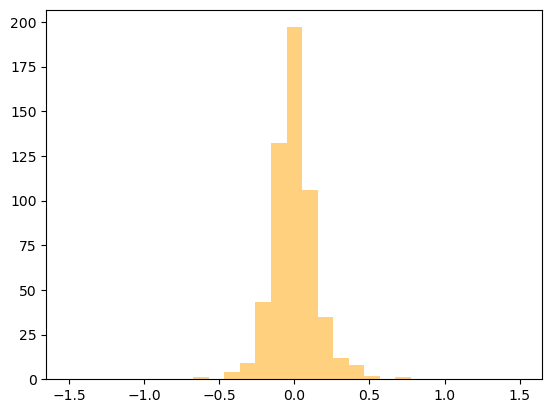

In [8]:
def plot_pd_panel(ax, feature, rf, X, feature_cols, nbins=10, method="recursion"):
    # Full feature matrix in training order
    X_pd = X[feature_cols]

    # Partial dependence for this feature
    res = partial_dependence(
        estimator=rf,
        X=X_pd,
        features=[feature],
        method=method,
        #percentiles=(0.00, 1.00)
    )
    x_grid = res["grid_values"][0]
    y_grid = res["average"][0]

    # PD points
    ax.scatter(x_grid, y_grid, alpha=0.6, s=30, color="orange", label="PD (marginalized)", zorder = 4)

    # Raw + binned overlay (your helper)
    global point_kwargs
    point_kwargs = {**point_kwargs, "label": "Raw Data"}
    scatter_with_errors(ax, feature, nbins=nbins)

    # Dummy handle for legend entry
    ax.errorbar([], [], fmt="o", color="blue", markersize=4, label="Binned Raw data")

    ax.set_xlabel(feature)
    ax.set_ylabel(r"$\Delta \mu$")


# --- 3x3 grid for 9 features ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharey=True)

# Row 1
# plot_pd_panel(axes[0, 0], "LOGMSTAR", rf, X, feature_cols, nbins=nbins, method="recursion")
plot_pd_panel(axes[0, 1], "c",        rf, X, feature_cols, nbins=nbins, method="recursion")
# Existing full-range fit
coef_c = np.polyfit(df["c"], y, 1)
x_fit_c = np.linspace(df["c"].min(), df["c"].max(), 200)
axes[0, 1].plot(x_fit_c, np.polyval(coef_c, x_fit_c), color="blue", linewidth=2)
print("Linear fit coefficients for c (slope, intercept):", coef_c)

# Limited-range fit: -0.2 <= c <= 0.3
mask_c = (df["c"] >= -0.2) & (df["c"] <= 0.3)
coef_c_limited = np.polyfit(df.loc[mask_c, "c"], y[mask_c], 1)
x_fit_c_limited = np.linspace(-0.2, 0.3, 200)
axes[0, 1].plot(x_fit_c_limited, np.polyval(coef_c_limited, x_fit_c_limited), color="green", linewidth=2)
print("Linear fit coefficients for c (limited range, slope, intercept):", coef_c_limited)

y_predict = rf.predict(X[feature_cols])
mask_c = (df["c"] >= -0.2) & (df["c"] <= 0.3)
coef_c_limited = np.polyfit(df.loc[mask_c, "c"], y_predict[mask_c], 1)
x_fit_c_limited = np.linspace(-0.2, 0.3, 200)
axes[0, 1].plot(x_fit_c_limited, np.polyval(coef_c_limited, x_fit_c_limited), color="red", linewidth=2)
print("Linear fit coefficients for c (ml prediction, slope, intercept):", coef_c_limited)


plot_pd_panel(axes[0, 2], "x1",       rf, X, feature_cols, nbins=nbins, method="recursion")
coef_x1 = np.polyfit(df["x1"], y, 1)
x_fit_x1 = np.linspace(df["x1"].min(), df["x1"].max(), 200)
axes[0, 2].plot(x_fit_x1, np.polyval(coef_x1, x_fit_x1), color="blue", linewidth=2)
print("Linear fit coefficients for x1 (slope, intercept):", coef_x1)  



# Row 2
# plot_pd_panel(axes[1, 0], "SFR",      rf, X, feature_cols, nbins=nbins, method="recursion")
# plot_pd_panel(axes[1, 1], "VDISP",    rf, X, feature_cols, nbins=nbins, method="recursion")
# plot_pd_panel(axes[1, 2], "DN4000",   rf, X, feature_cols, nbins=nbins, method="recursion")

# Row 3
plot_pd_panel(axes[2, 0], "SDSS_g_minus_r", rf, X, feature_cols, nbins=nbins, method="recursion")
# plot_pd_panel(axes[2, 1], "AGE",            rf, X, feature_cols, nbins=nbins, method="recursion")
# plot_pd_panel(axes[2, 2], "redshift",       rf, X, feature_cols, nbins=20, method="recursion")
axes[2, 2].set_xlim(0, 0.1)

# One legend for the whole figure (cleaner than 9 legends)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

y_predict = rf.predict(X[feature_cols])
mu_bins = np.linspace(-1.5, 1.5, 30)
plt.hist(y_predict-y, bins=mu_bins, alpha=0.5, color="orange", label="PD (marginalized)")
print(np.std(y_predict-y))



# Machine Learning Optimizatin #

In [9]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define NMAD
def nmad(y_true, y_pred):
    return 1.4826 * np.median(np.abs(y_pred - y_true))

# Parameter grid
learning_rates = [0.01, 0.03, 0.05]
n_estimators_list = [500, 1000, 2000]
max_depth_list = [1, 2, 3]
subsample_list = [0.7, 0.9]

results = []

for lr in learning_rates:
    for ne in n_estimators_list:
        for md in max_depth_list:
            for ss in subsample_list:

                gbr = GradientBoostingRegressor(
                    learning_rate=lr,
                    n_estimators=ne,
                    max_depth=md,
                    subsample=ss,
                    min_samples_leaf=5,
                    max_features="sqrt",
                    random_state=42
                )

                y_pred = cross_val_predict(gbr, X, y, cv=cv)

                score = nmad(y, y_pred)

                results.append({
                    "learning_rate": lr,
                    "n_estimators": ne,
                    "max_depth": md,
                    "subsample": ss,
                    "NMAD": score
                })

# Convert to DataFrame
res_df = pd.DataFrame(results)

# Sort by NMAD
res_df = res_df.sort_values("NMAD")

print("\nTop 10 configurations by NMAD:\n")
display(res_df.head(10))

best_config = res_df.iloc[0]
print("\nBest configuration:")
print(best_config)


Top 10 configurations by NMAD:



,learning_rate,n_estimators,max_depth,subsample,NMAD
15,0.01,2000,2,0.9,0.149686
24,0.03,1000,1,0.7,0.150855
11,0.01,1000,3,0.9,0.151425
14,0.01,2000,2,0.7,0.151797
10,0.01,1000,3,0.7,0.152615
21,0.03,500,2,0.9,0.153386
36,0.05,500,1,0.7,0.153417
23,0.03,500,3,0.9,0.153892
8,0.01,1000,2,0.7,0.154110
26,0.03,1000,2,0.7,0.154149



Best configuration:
learning_rate       0.010000
n_estimators     2000.000000
max_depth           2.000000
subsample           0.900000
NMAD                0.149686
Name: 15, dtype: float64
